# DM intermédiaire - Python Data Science

Analyse des résultats électoraux en France à partir des données mises à disposition sur data.gouv.fr.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from great_tables import GT
from cartiflette import carti_download

from utils import plot_surrepresentation, carte_candidat

In [ ]:
df = pd.read_csv(
    "https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb"
)

/tmp/ipykernel_126389/3244296778.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [ ]:
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528675 entries, 0 to 528674
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   code_departement     528675 non-null  object
 1   libelle_departement  528675 non-null  object
 2   code_commune         528675 non-null  int64 
 3   libelle_commune      528675 non-null  object
 4   prenom               422940 non-null  object
 5   nom                  528675 non-null  object
 6   voix                 528675 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 28.2+ MB


Le code d’import fourni dans l’énoncé a été conservé. La colonne code_commune étant ensuite utilisée comme identifiant, une conversion en chaîne de caractères est effectuée au moment du traitement pour éviter les problèmes de format.

1. Explorations générales

## Question 1

On reconstruit un code commune complet en concaténant le code du département et le code de la commune sur 3 chiffres.
On crée ensuite une variable `candidat` en concaténant le prénom et le nom, sans supprimer les abstentions, blancs et nuls.

La variable `prenom` contient des valeurs manquantes. Il faut donc en tenir compte lors de la création de la variable `candidat`, afin de conserver les lignes correspondant aux abstentions, blancs et nuls.

Pour construire `code_commune`, il faut distinguer les départements métropolitains et les DROM.  
En effet, dans les DROM, une concaténation directe avec une commune sur 3 chiffres produit un identifiant trop long (par exemple `971101` au lieu de `97101`).  
On adapte donc la reconstruction selon la longueur du code département.

In [ ]:
# Reconstruction robuste du code commune
dep = df["code_departement"].astype(str).str.strip()
com = df["code_commune"].astype(str).str.strip()

is_drom = dep.str.fullmatch(r"\d{3}", na=False)

df["code_commune"] = (
    dep
    + com.str.zfill(3).where(~is_drom, com.str[-2:].str.zfill(2))
)

df[["code_departement", "libelle_commune", "code_commune"]].head()

,code_departement,libelle_commune,code_commune
0,01,L'Abergement-Clémenciat,01001
1,01,L'Abergement-de-Varey,01002
2,01,Ambérieu-en-Bugey,01004
3,01,Ambérieux-en-Dombes,01005
4,01,Ambléon,01006


In [ ]:
# Création de la variable candidat
df["candidat"] = (
    df["prenom"].fillna("").str.strip()
    + " "
    + df["nom"].fillna("").str.strip()
).str.strip()

df[["prenom", "nom", "candidat"]].head(10)

,prenom,nom,candidat
0,Nathalie,ARTHAUD,Nathalie ARTHAUD
1,Nathalie,ARTHAUD,Nathalie ARTHAUD
2,Nathalie,ARTHAUD,Nathalie ARTHAUD
3,Nathalie,ARTHAUD,Nathalie ARTHAUD
4,Nathalie,ARTHAUD,Nathalie ARTHAUD
5,Nathalie,ARTHAUD,Nathalie ARTHAUD
6,Nathalie,ARTHAUD,Nathalie ARTHAUD
7,Nathalie,ARTHAUD,Nathalie ARTHAUD
8,Nathalie,ARTHAUD,Nathalie ARTHAUD
9,Nathalie,ARTHAUD,Nathalie ARTHAUD


## Question 2

On cherche à compter le nombre de candidats à l'élection présidentielle de 2022.
Il faut exclure les votes non exprimés et les abstentions, qui ne correspondent pas à des candidats.

In [ ]:
non_candidats = ["abstentions", "blancs", "nuls"]

candidats = df.loc[
    ~df["candidat"].str.lower().isin(non_candidats),
    "candidat"
].nunique()

f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

## Question 3

On calcule les résultats nationaux de chaque candidat au premier tour de l'élection présidentielle de 2022.
Le score est calculé en pourcentage des suffrages exprimés, c'est-à-dire en excluant les abstentions, les bulletins blancs et les bulletins nuls.

In [ ]:
score_national = (
    df.loc[~df["candidat"].str.lower().isin(["abstentions", "blancs", "nuls"])]
    .groupby("candidat", as_index=False)["voix"]
    .sum()
    .rename(columns={"voix": "Nombre votes (total)"})
)

score_national["Score (% votes exprimés)"] = (
    score_national["Nombre votes (total)"]
    / score_national["Nombre votes (total)"].sum()
)

score_national = score_national.sort_values(
    "Nombre votes (total)", ascending=False
).reset_index(drop=True)

(
    GT(score_national)
    .tab_header(
        title="Résultats du premier tour",
        subtitle="Élection présidentielle française — 10 avril 2022"
    )
    .fmt_integer(columns="Nombre votes (total)", use_seps=True, sep_mark=" ")
    .fmt_percent(columns="Score (% votes exprimés)", decimals=2)
)

GT(_tbl_data=                 candidat  Nombre votes (total)  Score (% votes exprimés)
0         Emmanuel MACRON               9783058                  0.278458
1           Marine LE PEN               8133828                  0.231516
2      Jean-Luc MÉLENCHON               7712520                  0.219524
3            Éric ZEMMOUR               2485226                  0.070738
4        Valérie PÉCRESSE               1679001                  0.047790
5           Yannick JADOT               1627853                  0.046334
6           Jean LASSALLE               1101387                  0.031349
7          Fabien ROUSSEL                802422                  0.022840
8   Nicolas DUPONT-AIGNAN                725176                  0.020641
9            Anne HIDALGO                616478                  0.017547
10        Philippe POUTOU                268904                  0.007654
11       Nathalie ARTHAUD                197094                  0.005610, _body=<great_tables._gt_data.Body object at 0x7fb3996468b0>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fb39da1d450>, _spanners=Spanners([]), _heading=Heading(title='Résultats du premier tour', subtitle='Élection présidentielle française — 10 avril 2022', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fb3995fac40>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fb394fb5b50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fb39da1d810>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fb3995fad70>, <great_tables._gt_data.FormatInfo object at 0x7fb394fb7d10>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value'

2. Comparaison des scores départements aux moyennes nationales.

## Question 4

On construit un dataframe `score_departements` contenant, pour chaque département et pour chaque candidat, le nombre total de voix ainsi que le score en pourcentage des suffrages exprimés dans le département.

On exclut les abstentions, les bulletins blancs et les bulletins nuls afin de ne conserver que les suffrages exprimés.

In [ ]:
score_departements = (
    df.loc[~df["candidat"].str.lower().isin(["abstentions", "blancs", "nuls"])]
    .groupby(["code_departement", "candidat"], as_index=False)["voix"]
    .sum()
    .rename(columns={"voix": "votes"})
)

totaux_departements = (
    score_departements.groupby("code_departement", as_index=False)["votes"]
    .sum()
    .rename(columns={"votes": "total_exprimes"})
)

score_departements = score_departements.merge(
    totaux_departements,
    on="code_departement",
    how="left",
    validate="m:1"
)

score_departements["score"] = (
    score_departements["votes"] / score_departements["total_exprimes"]
)

score_departements = (
    score_departements
    .sort_values(["code_departement", "votes"], ascending=[True, False])
    .reset_index(drop=True)
    [["code_departement", "candidat", "votes", "score"]]
)

score_departements.head()

,code_departement,candidat,votes,score
0,01,Emmanuel MACRON,92206,0.276875
1,01,Marine LE PEN,86755,0.260507
2,01,Jean-Luc MÉLENCHON,57832,0.173657
3,01,Éric ZEMMOUR,27530,0.082667
4,01,Valérie PÉCRESSE,17572,0.052765


On vérifie ensuite le contenu du dataframe pour le département de l’Aude (`11`).

In [ ]:
score_departements.loc[score_departements["code_departement"] == "11"].style.format({
    "votes": lambda x: f"{x:,}".replace(",", " "),
    "score": lambda x: f"{x:.2%}"
})

,code_departement,candidat,votes,score
120,11,Marine LE PEN,64 027,30.14%
121,11,Emmanuel MACRON,43 104,20.29%
122,11,Jean-Luc MÉLENCHON,42 039,19.79%
123,11,Éric ZEMMOUR,18 434,8.68%
124,11,Jean LASSALLE,12 382,5.83%
125,11,Valérie PÉCRESSE,7 350,3.46%
126,11,Yannick JADOT,6 322,2.98%
127,11,Anne HIDALGO,6 166,2.90%
128,11,Fabien ROUSSEL,5 622,2.65%
129,11,Nicolas DUPONT-AIGNAN,4 206,1.98%


## Question 5

On complète le dataframe `score_departements` en y ajoutant, pour chaque candidat, les résultats observés au niveau national.  
Cela permet de comparer le score obtenu dans un département au score moyen obtenu en France entière.

In [ ]:
score_national = (
    df.loc[~df["candidat"].str.lower().isin(["abstentions", "blancs", "nuls"])]
    .groupby("candidat", as_index=False)["voix"]
    .sum()
    .rename(columns={"voix": "votes_national"})
)

score_national["score_national"] = (
    score_national["votes_national"] / score_national["votes_national"].sum()
)

score_departements = (
    score_departements
    .rename(columns={
        "votes": "votes_departement",
        "score": "score_departement"
    })
    .merge(score_national, on="candidat", how="left", validate="m:1")
)

score_departements.head()

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,01,Emmanuel MACRON,92206,0.276875,9783058,0.278458
1,01,Marine LE PEN,86755,0.260507,8133828,0.231516
2,01,Jean-Luc MÉLENCHON,57832,0.173657,7712520,0.219524
3,01,Éric ZEMMOUR,27530,0.082667,2485226,0.070738
4,01,Valérie PÉCRESSE,17572,0.052765,1679001,0.047790


On vérifie ensuite le résultat obtenu pour le département de l’Aude (`11`), afin de comparer les scores départementaux aux scores nationaux pour chaque candidat.

In [ ]:
score_departements.loc[
    score_departements["code_departement"] == "11"
].style.format({
    "votes_departement": lambda x: f"{x:,}".replace(",", " "),
    "score_departement": lambda x: f"{x:.2%}",
    "votes_national": lambda x: f"{x:,}".replace(",", " "),
    "score_national": lambda x: f"{x:.2%}"
})

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
120,11,Marine LE PEN,64 027,30.14%,8 133 828,23.15%
121,11,Emmanuel MACRON,43 104,20.29%,9 783 058,27.85%
122,11,Jean-Luc MÉLENCHON,42 039,19.79%,7 712 520,21.95%
123,11,Éric ZEMMOUR,18 434,8.68%,2 485 226,7.07%
124,11,Jean LASSALLE,12 382,5.83%,1 101 387,3.13%
125,11,Valérie PÉCRESSE,7 350,3.46%,1 679 001,4.78%
126,11,Yannick JADOT,6 322,2.98%,1 627 853,4.63%
127,11,Anne HIDALGO,6 166,2.90%,616 478,1.75%
128,11,Fabien ROUSSEL,5 622,2.65%,802 422,2.28%
129,11,Nicolas DUPONT-AIGNAN,4 206,1.98%,725 176,2.06%


## Question 6

On crée une variable `surrepresentation` qui mesure, en relatif, l'écart entre le score départemental et le score national d'un candidat.

Une valeur positive indique que le candidat est surreprésenté dans le département par rapport à son niveau national. Une valeur négative indique au contraire une sous-représentation.

In [ ]:
score_departements["surrepresentation"] = (
    (score_departements["score_departement"] - score_departements["score_national"])
    / score_departements["score_national"]
)

# Affichage en pourcentage avec deux décimales pour améliorer la lisibilité

score_departements.head().style.format({
    "score_departement": "{:.2%}",
    "score_national": "{:.2%}",
    "surrepresentation": "{:.2%}"
})

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Emmanuel MACRON,92206,27.69%,9783058,27.85%,-0.57%
1,01,Marine LE PEN,86755,26.05%,8133828,23.15%,12.52%
2,01,Jean-Luc MÉLENCHON,57832,17.37%,7712520,21.95%,-20.89%
3,01,Éric ZEMMOUR,27530,8.27%,2485226,7.07%,16.86%
4,01,Valérie PÉCRESSE,17572,5.28%,1679001,4.78%,10.41%


## Question 7

On crée une fonction qui représente, pour un candidat donné, les principales surreprésentations départementales en valeur absolue.

La figure met en évidence les départements dans lesquels le candidat obtient un score relativement supérieur ou inférieur à son score national.

La fonction plot_surrepresentation() a été définie dans le fichier utils.py afin d’alléger le notebook principal et d’améliorer la lisibilité du code.

Exemple d’utilisation

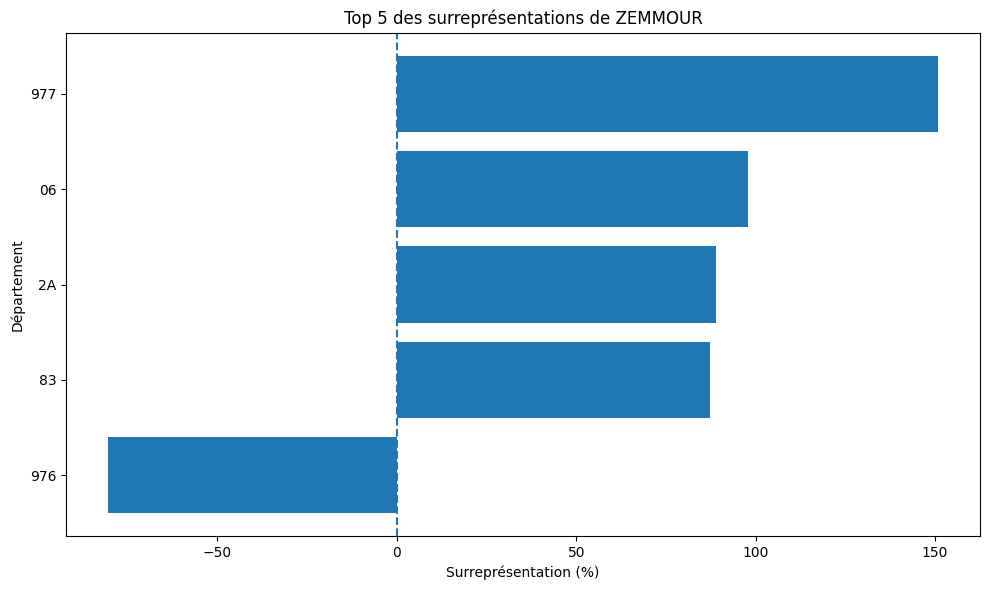

In [ ]:
plot_surrepresentation(score_departements, "Éric ZEMMOUR", top_n=5)

3. Un peu de cartographie

## Question 8

On crée une fonction qui restreint le dataframe `score_departements` à un candidat donné, sans modifier l'objet initial.

On effectue ensuite une jointure avec le fond de carte des départements afin de représenter cartographiquement la surreprésentation du candidat. On commence par tester cette fonction sur Marine Le Pen.

In [ ]:
from cartiflette import carti_download

departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

La fonction carte_candidat() a été définie dans le fichier utils.py afin de séparer les fonctions réutilisables du notebook principal.

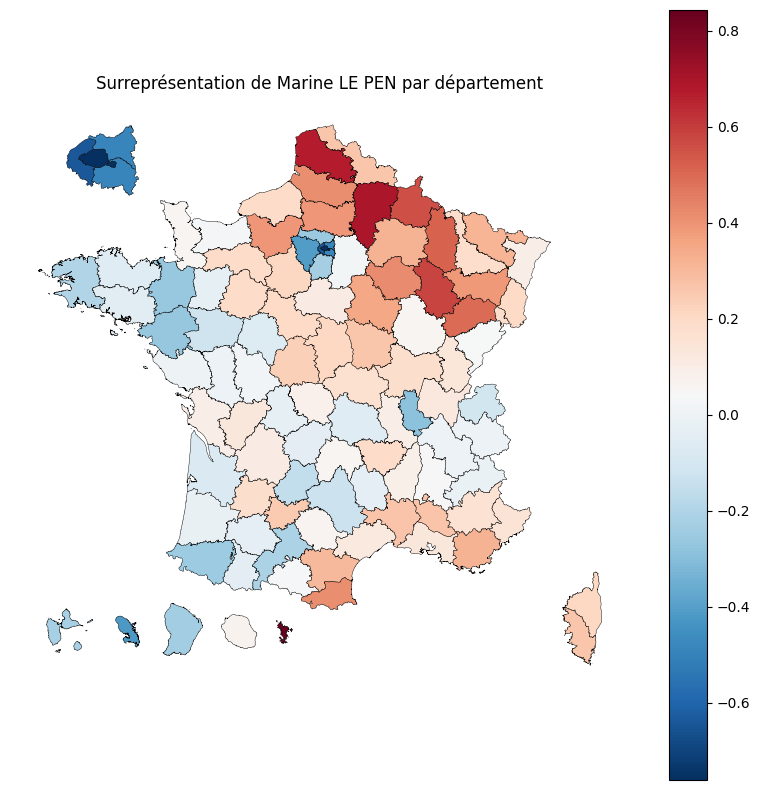

In [ ]:
carte_lepen = carte_candidat(score_departements, "Marine LE PEN", departement_borders)

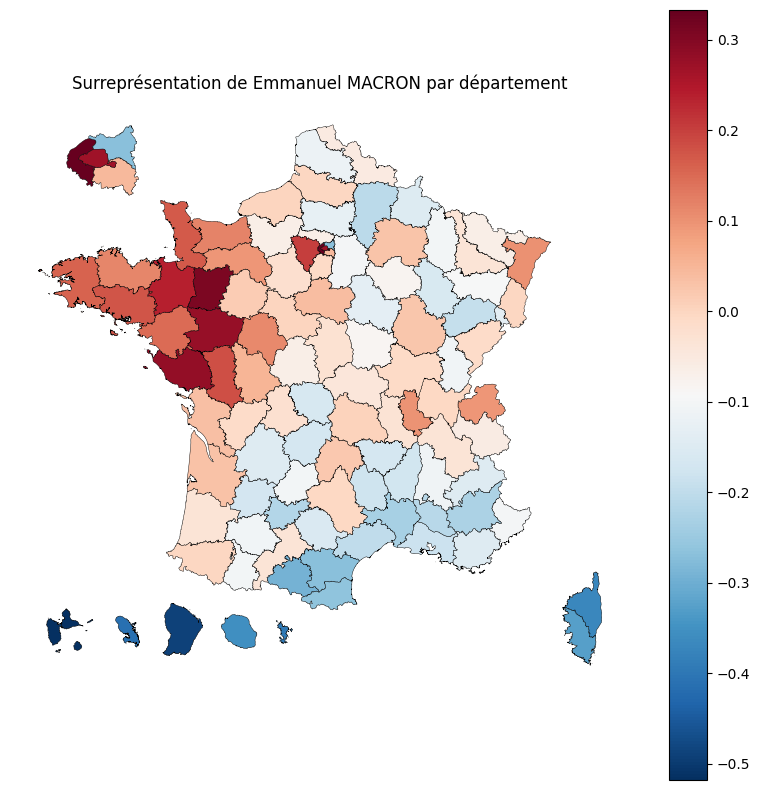

In [ ]:
carte_macron = carte_candidat(score_departements, "Emmanuel MACRON", departement_borders)

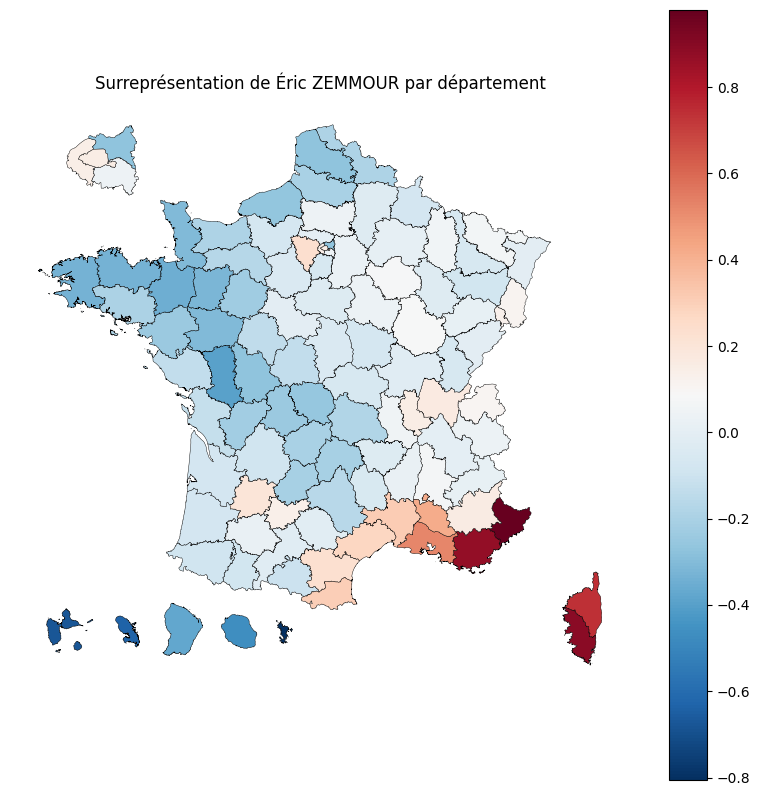

In [ ]:
carte_zemmour = carte_candidat(score_departements, "Éric ZEMMOUR", departement_borders)